# 实验二 卷积神经网络的应用及分析

本次实验基于 CIFAR10 数据集，包含以下四个任务：
1. 数据集准备与预处理
2. 简单卷积神经网络搭建与评估
3. 基础网络模型的优化与分析
4. 经典卷积神经网络架构（ResNet-18）的实现

## 1. 实验环境设置与数据预处理
利用 CUDA 进行加速计算，并在数据预处理中加入**数据增强**（随机水平翻转、随机裁剪）以提升模型的泛化能力。

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import time

# 检查并设置计算设备为 CUDA
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'当前使用的计算设备: {device}')

# ================= 数据预处理 =================
# 训练集：加入数据增强防止过拟合
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(), # 随机水平翻转
    transforms.RandomCrop(32, padding=4), # 随机裁剪
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# 测试集：只做标准化转换
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

batch_size = 128

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

当前使用的计算设备: cuda:0


为了方便后续重复使用，我们先定义一个**通用的模型训练与评估函数**。

In [2]:
def train_and_evaluate(model, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_loss_history = []
    train_acc_history = []
    test_acc_history = []
    
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_loss = running_loss / len(trainloader)
        epoch_acc = 100 * correct / total
        train_loss_history.append(epoch_loss)
        train_acc_history.append(epoch_acc)
        
        # 测试集评估
        model.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()
                
        test_acc = 100 * test_correct / test_total
        test_acc_history.append(test_acc)
        
        print(f'Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Train Acc: {epoch_acc:.2f}% - Test Acc: {test_acc:.2f}%')
        
    print(f'训练结束！总耗时: {(time.time() - start_time):.2f} 秒')
    return train_loss_history, train_acc_history, test_acc_history

def plot_metrics(train_loss, train_acc, test_acc, title):
    epochs = range(1, len(train_loss) + 1)
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, 'r-', marker='o', label='Train Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, 'b-', marker='o', label='Train Acc')
    plt.plot(epochs, test_acc, 'g-', marker='s', label='Test Acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

## 2. 简单卷积神经网络模型
按照经典范式：Conv -> Pool -> Conv -> Pool -> FC -> FC 搭建。

========== 训练 SimpleCNN ==========
Epoch [1/10] - Loss: 1.6201 - Train Acc: 40.87% - Test Acc: 52.89%
Epoch [2/10] - Loss: 1.3449 - Train Acc: 51.92% - Test Acc: 60.01%
Epoch [3/10] - Loss: 1.2110 - Train Acc: 56.77% - Test Acc: 62.27%
Epoch [4/10] - Loss: 1.1465 - Train Acc: 59.58% - Test Acc: 65.77%
Epoch [5/10] - Loss: 1.0849 - Train Acc: 61.62% - Test Acc: 65.98%
Epoch [6/10] - Loss: 1.0405 - Train Acc: 63.37% - Test Acc: 66.92%
Epoch [7/10] - Loss: 1.0028 - Train Acc: 64.80% - Test Acc: 68.37%
Epoch [8/10] - Loss: 0.9590 - Train Acc: 66.14% - Test Acc: 69.32%
Epoch [9/10] - Loss: 0.9410 - Train Acc: 67.12% - Test Acc: 70.17%
Epoch [10/10] - Loss: 0.9109 - Train Acc: 68.24% - Test Acc: 70.91%
训练结束！总耗时: 241.45 秒


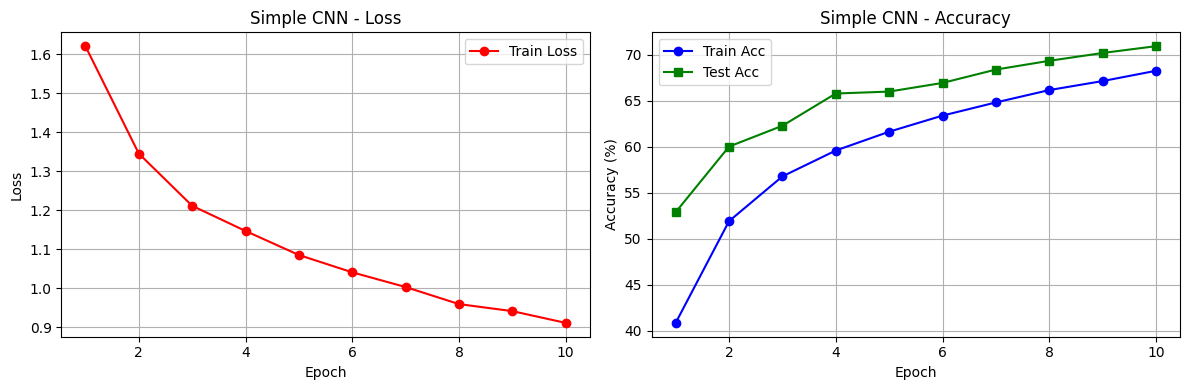

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 5, 1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 36, 3, 1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(1296, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 1296)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print('========== 训练 SimpleCNN ==========')
simple_net = SimpleCNN().to(device)
s_loss, s_train_acc, s_test_acc = train_and_evaluate(simple_net, epochs=10, lr=0.001)
plot_metrics(s_loss, s_train_acc, s_test_acc, 'Simple CNN')

## 3. 基础网络模型的优化与分析
在简单卷积网络的基础上引入：
1. **批量归一化 (Batch Normalization)**：加速收敛并缓解内部协变量偏移。
2. **Dropout层**：丢弃部分神经元，防止模型过拟合。
3. 增加了一层卷积使得特征提取能力更强。

========== 训练 Optimized CNN ==========
Epoch [1/10] - Loss: 1.5826 - Train Acc: 42.51% - Test Acc: 59.91%
Epoch [2/10] - Loss: 1.2889 - Train Acc: 53.95% - Test Acc: 61.53%
Epoch [3/10] - Loss: 1.1734 - Train Acc: 58.16% - Test Acc: 64.63%
Epoch [4/10] - Loss: 1.0951 - Train Acc: 61.27% - Test Acc: 67.75%
Epoch [5/10] - Loss: 1.0323 - Train Acc: 63.73% - Test Acc: 64.99%
Epoch [6/10] - Loss: 0.9932 - Train Acc: 65.06% - Test Acc: 71.35%
Epoch [7/10] - Loss: 0.9590 - Train Acc: 66.55% - Test Acc: 70.39%
Epoch [8/10] - Loss: 0.9287 - Train Acc: 67.81% - Test Acc: 72.79%
Epoch [9/10] - Loss: 0.8945 - Train Acc: 69.19% - Test Acc: 73.06%
Epoch [10/10] - Loss: 0.8652 - Train Acc: 70.02% - Test Acc: 74.47%
训练结束！总耗时: 222.96 秒


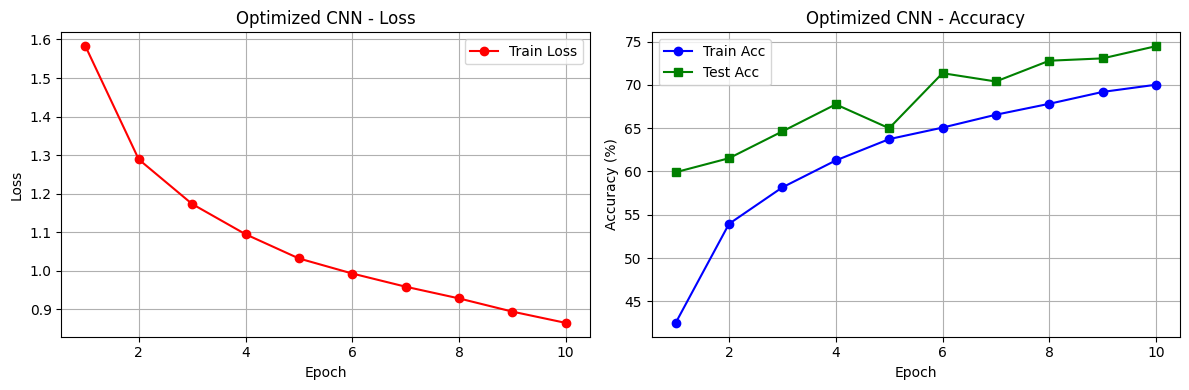

In [4]:
class OptimizedCNN(nn.Module):
    def __init__(self):
        super(OptimizedCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # 尺寸: 32 -> pool(16) -> pool(8)
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = x.view(-1, 128 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

print('========== 训练 Optimized CNN ==========')
opt_net = OptimizedCNN().to(device)
o_loss, o_train_acc, o_test_acc = train_and_evaluate(opt_net, epochs=10, lr=0.001)
plot_metrics(o_loss, o_train_acc, o_test_acc, 'Optimized CNN')

## 4. 经典卷积神经网络：ResNet-18
使用 PyTorch 自带的经典模型 ResNet-18。由于原始 ResNet-18 是为 224x224 的 ImageNet 设计的，而 CIFAR10 是 32x32 的小图。
为了避免刚开始就被过度下采样丢失特征，我们修改其：
1. 将第一层的大卷积核(`7x7`, `stride=2`) 改为小卷积核(`3x3`, `stride=1`)。
2. 移除第一层的最大池化层。
3. 将全连接层输出修改为 10 类。

========== 训练 ResNet-18 ==========
Epoch [1/10] - Loss: 1.3615 - Train Acc: 50.41% - Test Acc: 52.40%
Epoch [2/10] - Loss: 0.8802 - Train Acc: 68.60% - Test Acc: 70.47%
Epoch [3/10] - Loss: 0.6901 - Train Acc: 75.88% - Test Acc: 76.63%
Epoch [4/10] - Loss: 0.5725 - Train Acc: 80.27% - Test Acc: 78.54%
Epoch [5/10] - Loss: 0.5001 - Train Acc: 82.90% - Test Acc: 80.53%
Epoch [6/10] - Loss: 0.4485 - Train Acc: 84.57% - Test Acc: 83.12%
Epoch [7/10] - Loss: 0.4017 - Train Acc: 86.16% - Test Acc: 84.97%
Epoch [8/10] - Loss: 0.3640 - Train Acc: 87.50% - Test Acc: 85.93%
Epoch [9/10] - Loss: 0.3329 - Train Acc: 88.57% - Test Acc: 82.98%
Epoch [10/10] - Loss: 0.3045 - Train Acc: 89.40% - Test Acc: 85.54%
训练结束！总耗时: 605.88 秒


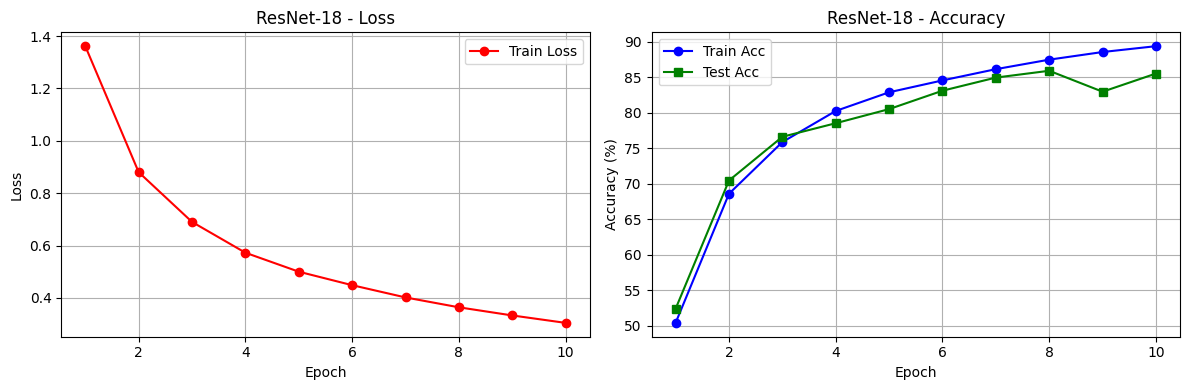

In [5]:
import torchvision.models as models

# 加载 ResNet-18，但不使用预训练权重（因为图像尺寸和数据集特性差异较大，我们从头训练）
resnet18 = models.resnet18(weights=None)

# 适配 CIFAR-10 的 32x32 尺寸
resnet18.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
resnet18.maxpool = nn.Identity() # 移除最大池化层

# 适配 CIFAR-10 的 10 分类输出
num_ftrs = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_ftrs, 10)

resnet18 = resnet18.to(device)

print('========== 训练 ResNet-18 ==========')
# ResNet 结构较深，我们仍训练10个Epoch进行对比验证
r_loss, r_train_acc, r_test_acc = train_and_evaluate(resnet18, epochs=10, lr=0.001)
plot_metrics(r_loss, r_train_acc, r_test_acc, 'ResNet-18')